# Jenelle's Analysis

# Shooting-To-Murder Conversion Rate

The purpose of this notebook is to analyze the following shooting-to-murder conversion rate by: 
 - Age
 - Gender
 - Year



In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [17]:
# Loading the dataset
df = pd.read_csv("../../data/processed/clean_data.csv")

#Printing out the columns, count of the non-null values, and the data type
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29000 entries, 0 to 28999
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Unnamed: 0                   29000 non-null  int64  
 1   incident_key                 29000 non-null  int64  
 2   occur_date                   29000 non-null  str    
 3   occur_time                   29000 non-null  str    
 4   boro                         29000 non-null  str    
 5   precinct                     29000 non-null  int64  
 6   jurisdiction_code            28998 non-null  float64
 7   statistical_murder_flag      29000 non-null  bool   
 8   perp_age_group               19703 non-null  str    
 9   perp_sex                     19704 non-null  str    
 10  perp_race                    19704 non-null  str    
 11  vic_age_group                29000 non-null  str    
 12  vic_sex                      29000 non-null  str    
 13  vic_race                   

In [18]:
# Printing the first 10 columns of the dataframe
df.head(10)

,Unnamed: 0,incident_key,occur_date,occur_time,boro,precinct,jurisdiction_code,statistical_murder_flag,perp_age_group,perp_sex,...,:created_at,:updated_at,:@computed_region_yeji_bk3q,:@computed_region_92fq_4b7q,:@computed_region_sbqj_enih,:@computed_region_efsh_h5xi,:@computed_region_f5dn_yrer,location_desc,loc_of_occur_desc,loc_classfctn_desc
0,0,209281500,2020-02-08T00:00:00.000,12:13:00,QUEENS,115,0.0,True,25-44,M,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,3.0,21.0,73.0,14510.0,65.0,NaN,NaN,NaN
1,1,209281497,2020-02-08T00:00:00.000,02:20:00,BROOKLYN,76,0.0,True,25-44,M,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,2.0,7.0,48.0,13514.0,14.0,NaN,NaN,NaN
2,2,209281498,2020-02-07T00:00:00.000,22:50:00,BROOKLYN,75,0.0,False,25-44,M,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,2.0,37.0,47.0,17214.0,45.0,NaN,NaN,NaN
3,3,209099251,2020-02-05T00:00:00.000,04:02:00,QUEENS,101,0.0,False,NaN,NaN,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,3.0,47.0,59.0,20529.0,51.0,MULTI DWELL - APT BUILD,NaN,NaN
4,4,209098666,2020-02-05T00:00:00.000,23:13:00,MANHATTAN,34,0.0,False,18-24,M,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,4.0,39.0,22.0,13098.0,47.0,MULTI DWELL - APT BUILD,NaN,NaN
5,5,209099250,2020-02-05T00:00:00.000,11:51:00,QUEENS,101,0.0,False,NaN,NaN,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:34.986Z,3.0,47.0,59.0,20529.0,51.0,NaN,NaN,NaN
6,6,209029422,2020-02-04T00:00:00.000,18:43:00,BROOKLYN,75,0.0,True,18-24,F,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,2.0,25.0,47.0,17215.0,45.0,NaN,NaN,NaN
7,7,209029422,2020-02-04T00:00:00.000,18:43:00,BROOKLYN,75,0.0,True,18-24,M,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:34.986Z,2.0,25.0,47.0,17215.0,45.0,NaN,NaN,NaN
8,8,208955529,2020-02-03T00:00:00.000,21:12:00,BRONX,47,0.0,True,45-64,M,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,5.0,40.0,30.0,11608.0,29.0,NaN,NaN,NaN
9,9,208899477,2020-02-02T00:00:00.000,15:55:00,BROOKLYN,84,0.0,False,<18,M,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,2.0,38.0,54.0,17619.0,68.0,NaN,NaN,NaN


In [68]:
# Set the style of the charts
sns.set_theme(style="whitegrid")

This analytical project will use the following  columns to understand the shooting-to-murder conversion rate. 
- statistical_murder_flag : True (the victim died) or False (the victim survived) 
- perp_age_group 
- perp_sex
- occur_date

# Shooting-To-Murder Conversion Rate 

In [69]:
#Counting the total number of true and false values in the 
murder_conversion = df['statistical_murder_flag'].value_counts()

murder_conversion


statistical_murder_flag
False    23396
True      5604
Name: count, dtype: int64

In [70]:
murder_conversion_percentage= df['statistical_murder_flag'].value_counts(normalize=True) * 100

murder_conversion_percentage

statistical_murder_flag
False    80.675862
True     19.324138
Name: proportion, dtype: float64

In [71]:
# Dataframe displaying the count and percentages of the 

conversion_table = pd.DataFrame({
    'Total Incidents': murder_conversion,
    'Percentage': murder_conversion_percentage
}).reset_index()

conversion_table

,statistical_murder_flag,Total Incidents,Percentage
0,False,23396,80.675862
1,True,5604,19.324138


/var/folders/jk/419dr761613fkh_2fm3hm24w0000gn/T/ipykernel_40352/2566597019.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='statistical_murder_flag', y='Total Incidents', data=conversion_table, palette='Reds_d')


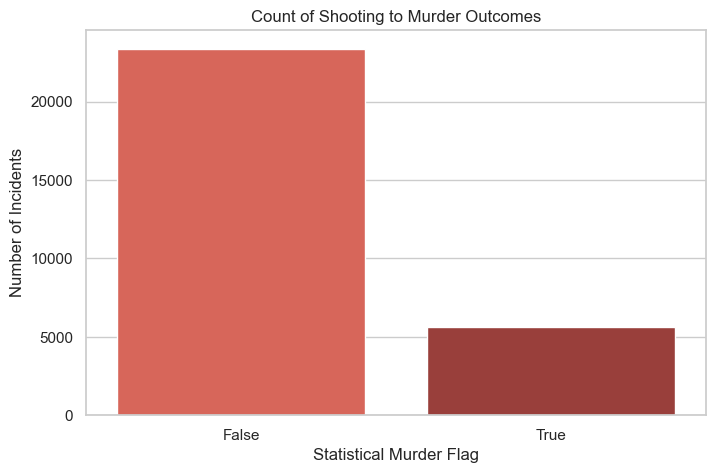

In [85]:
#Sets the chart window to 8 inches wide and 5 inches tall
plt.figure(figsize=(8, 5))

#Using the seaborn library creating a bar chart to display the conversion count
sns.barplot(x='statistical_murder_flag', y='Total Incidents', data=conversion_table, palette='Reds_d')


#Formatting Titles/labels
plt.title('Count of Shooting to Murder Outcomes')
plt.xlabel('Statistical Murder Flag')
plt.ylabel('Number of Incidents')
plt.show()

/var/folders/jk/419dr761613fkh_2fm3hm24w0000gn/T/ipykernel_40352/3000921970.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='statistical_murder_flag', y='Percentage', data=conversion_table, palette='Reds_d')


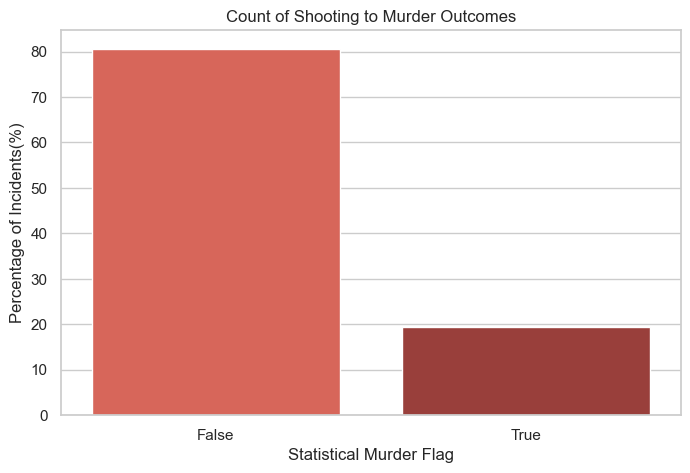

In [ ]:
#Sets the chart window to 8 inches wide and 5 inches tall
plt.figure(figsize=(8, 5))

#Using the seaborn library creating a bar chart to display the conversion percentage
sns.barplot(x='statistical_murder_flag', y='Percentage', data=conversion_table, palette='Reds_d')


#Formatting Titles/labels
plt.title('Count of Shooting to Murder Outcomes')
plt.xlabel('Statistical Murder Flag')
plt.ylabel('Percentage of Incidents(%)')
plt.show()

The above visualizations tells us that approximately 80% of shootings resulted in the victim surviving between 2006 and 2024.

# Shooting-To-Murder Conversion Rate by Age Group

In [19]:
#Groups by age group [perp_age_group]and murder conversion [statistical_murder_flag]
age_conversion = df.groupby('perp_age_group')['statistical_murder_flag'].mean().reset_index()

age_conversion

,perp_age_group,statistical_murder_flag
0,(null),0.141892
1,1020,0.000000
2,1028,0.000000
3,18-24,0.209980
4,2021,0.000000
5,224,0.000000
6,25-44,0.266656
7,45-64,0.346003
8,65+,0.378788
9,940,0.000000


In [ ]:
# Adds the conversion_rate column to calculate the percentage by multiplying 100 to the statistical_murder_flag column
age_conversion['conversion_rate(%)'] = age_conversion['statistical_murder_flag'] * 100

age_conversion

,perp_age_group,statistical_murder_flag,conversion_rate(%)
0,(null),0.141892,14.189189
1,1020,0.000000,0.000000
2,1028,0.000000,0.000000
3,18-24,0.209980,20.997985
4,2021,0.000000,0.000000
5,224,0.000000,0.000000
6,25-44,0.266656,26.665586
7,45-64,0.346003,34.600262
8,65+,0.378788,37.878788
9,940,0.000000,0.000000


In [ ]:
# Filters out 1022, UNKNOWN from the age group [perp_age_group] column
valid_ages = ['<18', '18-24', '25-44', '45-64', '65+']

age_conversion = age_conversion[age_conversion['perp_age_group'].isin(valid_ages)]

age_conversion

,perp_age_group,statistical_murder_flag,conversion_rate(%)
3,18-24,0.209980,20.997985
6,25-44,0.266656,26.665586
7,45-64,0.346003,34.600262
8,65+,0.378788,37.878788
10,<18,0.183429,18.342857


/var/folders/jk/419dr761613fkh_2fm3hm24w0000gn/T/ipykernel_49714/3114225581.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='perp_age_group', y='conversion_rate(%)', data=age_conversion, order=valid_ages, palette='Purples_d')


<Axes: xlabel='perp_age_group', ylabel='conversion_rate(%)'>

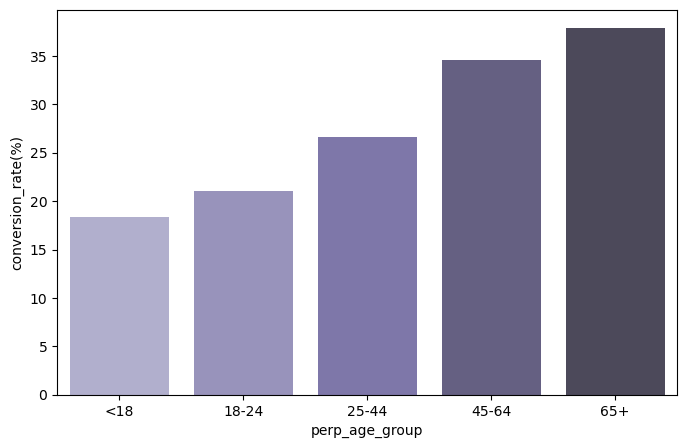

In [23]:
#Sets the chart window to 8 inches wide and 5 inches tall
plt.figure(figsize=(8, 5))

#Using the seaborn library creating a bar chart ordering by youngest to oldest of the conversion rate %
sns.barplot(x='perp_age_group', y='conversion_rate(%)', data=age_conversion, order=valid_ages, palette='Purples_d')

This bar chart shows that 65+ age group has the highest shooting-to-murder conversion rate at 37%.

# Shooting-To-Murder Conversion Rate by Gender

In [ ]:
#Groups by gender [perp_sex]and murder conversion [statistical_murder_flag]
gender_conversion = df.groupby('perp_sex')['statistical_murder_flag'].mean().reset_index()

gender_conversion

,perp_sex,statistical_murder_flag
0,(null),0.141892
1,F,0.273731
2,M,0.215251
3,U,0.047443


In [31]:
# Adds the percentage column to calculate the percentage by multiplying 100 to the statistical_murder_flag column
gender_conversion['percentage(%)'] = gender_conversion['statistical_murder_flag'] * 100

gender_conversion

,perp_sex,statistical_murder_flag,percentage(%)
0,(null),0.141892,14.189189
1,F,0.273731,27.373068
2,M,0.215251,21.525132
3,U,0.047443,4.744255


In [33]:

valid_gender = ['F', 'M']

# Filters out (null) and U from the gender [perp_perp] column
gender_conversion = gender_conversion[gender_conversion['perp_sex'].isin(valid_gender)]

gender_conversion

,perp_sex,statistical_murder_flag,percentage(%)
1,F,0.273731,27.373068
2,M,0.215251,21.525132


/var/folders/jk/419dr761613fkh_2fm3hm24w0000gn/T/ipykernel_49714/1434430986.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='perp_sex', y='percentage(%)', data=gender_conversion, palette='Greens_d')


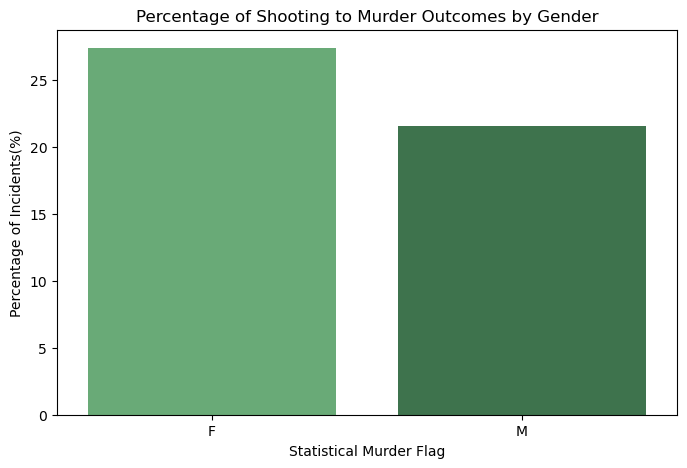

In [35]:
#Sets the chart window to 8 inches wide and 5 inches tall
plt.figure(figsize=(8, 5))

#Using the seaborn library creating a bar chart to display the conversion percentage
sns.barplot(x='perp_sex', y='percentage(%)', data=gender_conversion, palette='Greens_d')


#Formatting Titles/labels
plt.title('Percentage of Shooting to Murder Outcomes by Gender')
plt.xlabel('Statistical Murder Flag')
plt.ylabel('Percentage of Incidents(%)')
plt.show()

This bar graph shows that female perpertrators have a shooting to murder conversion rate of 27%  while male perpertrators are at 21%. 

Next analysis we could do here is look at the gender of the victims.

In [45]:
# Converting the occur_date column from  a str into a  Datetime column
df['occur_date'] = pd.to_datetime(df['occur_date'])

# Extractinfg the year
df['year'] = df['occur_date'].dt.year


valid_year = df['year'].unique()

array([2020, 2019, 2010, 2009, 2011, 2012, 2008, 2007, 2014, 2013, 2006,
       2015, 2018, 2017, 2016, 2024, 2023, 2022, 2021], dtype=int32)

In [49]:
date_conversion = df.groupby(df['year'])['statistical_murder_flag'].mean().reset_index()

date_conversion


,year,statistical_murder_flag
0,2006,0.216629
1,2007,0.197668
2,2008,0.184788
3,2009,0.190372
4,2010,0.211820
5,2011,0.192367
6,2012,0.167734
7,2013,0.166542
8,2014,0.170082
9,2015,0.197350


In [50]:
# Adds the conversion_rate column to calculate the percentage by multiplying 100 to the statistical_murder_flag column
date_conversion['date_conversion_rate(%)'] = date_conversion['statistical_murder_flag'] * 100

date_conversion

,year,statistical_murder_flag,date_conversion_rate(%)
0,2006,0.216629,21.662853
1,2007,0.197668,19.766826
2,2008,0.184788,18.478816
3,2009,0.190372,19.037199
4,2010,0.211820,21.182008
5,2011,0.192367,19.236720
6,2012,0.167734,16.773442
7,2013,0.166542,16.654220
8,2014,0.170082,17.008197
9,2015,0.197350,19.735007


In [54]:
date_conversion.max()

year                       2024.000000
statistical_murder_flag       0.216629
date_conversion_rate(%)      21.662853
dtype: float64

In [55]:
date_conversion.min()

year                       2006.000000
statistical_murder_flag       0.166542
date_conversion_rate(%)      16.654220
dtype: float64

/var/folders/jk/419dr761613fkh_2fm3hm24w0000gn/T/ipykernel_49714/1115313934.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='year', y='statistical_murder_flag', data=date_conversion, palette='Reds')


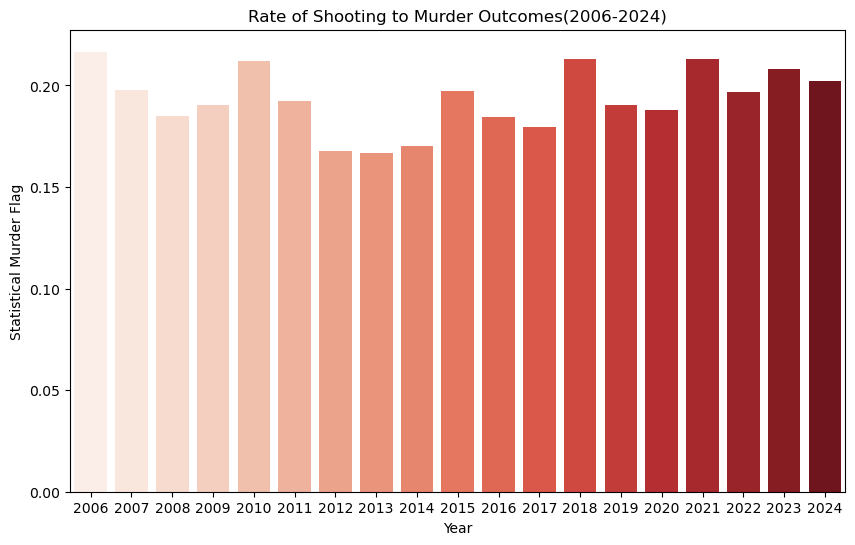

In [ ]:
#Sets the chart window to 8 inches wide and 5 inches tall
plt.figure(figsize=(10, 6))

#Using the seaborn library creating a bar chart to display the conversion count
sns.barplot(x='year', y='statistical_murder_flag', data=date_conversion, palette='Reds')


#Formatting Titles/labels
plt.title('Rate of Shooting to Murder Outcomes(2006-2024)')
plt.xlabel('Year')
plt.ylabel('Statistical Murder Flag')
plt.show()

# remember to push changes boo 